<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TimeA009: Memory Gradient Scan
Radius | Entropy Slope | Memory Retention | Irreversibility Index | Persistence
    10 |        0.21412 |           0.99827 |             104.54451 |     0.34678
    20 |        0.21628 |           0.99842 |             108.79442 |     0.35010
    30 |        0.21571 |           0.99838 |             106.78195 |     0.34880
    40 |        0.21319 |           0.99826 |             110.58196 |     0.34875


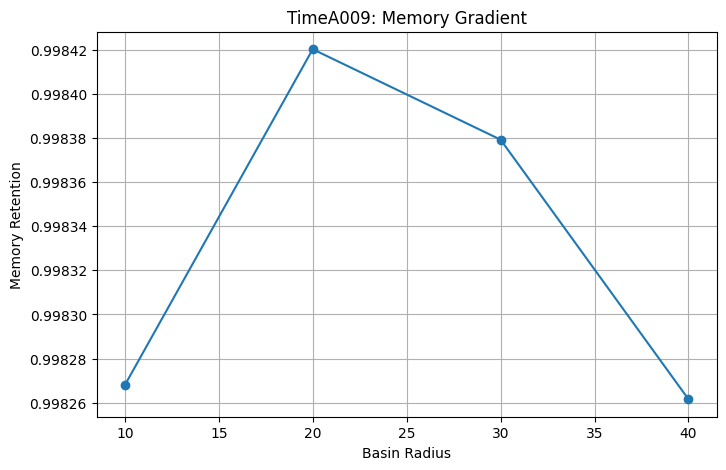

In [ ]:
# 🧠 TimeA009: The Memory Gradient
# Scanning basin depth to modulate entropy retention and irreversibility
# Author: Chris & Copilot | Arc V: Entropic Ascent | ACT033
# Reproducibility Tag: TimeA009_v1

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100  # lattice size
T = 200  # timesteps
curvature_strength = 0.5
xi_locking = True
bias_strength = 0.05
basin_radii = [10, 20, 30, 40]  # scan across basin sizes
seed = 42
np.random.seed(seed)

# --- Initialization ---
def initialize_lattice(N, curvature_strength):
    base = np.random.rand(N, N)
    curvature = curvature_strength * (np.sin(np.linspace(0, np.pi, N))[:, None])
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Basin Mask ---
def create_basin_mask(N, radius):
    x, y = np.meshgrid(np.arange(N), np.arange(N))
    center = N // 2
    mask = ((x - center)**2 + (y - center)**2) < radius**2
    return mask.astype(float)

# --- Evolution Function ---
def evolve_basin(lattice, xi_locking, bias_strength, basin_mask):
    entropy_map = np.gradient(lattice)[0]
    damping_mask = 1 - basin_mask
    bias_field = bias_strength * (entropy_map * basin_mask - 0.5 * entropy_map * damping_mask)
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_field
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, curvature_strength, xi_locking, bias_strength, basin_radius):
    lattice = initialize_lattice(N, curvature_strength)
    basin_mask = create_basin_mask(N, basin_radius)
    entropy_series = []
    cumulative_drift = np.zeros_like(lattice)
    for t in range(T):
        prev_lattice = lattice.copy()
        lattice = evolve_basin(lattice, xi_locking, bias_strength, basin_mask)
        cumulative_drift += lattice - prev_lattice
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series), cumulative_drift

# --- Metrics ---
def compute_metrics(entropy_series, cumulative_drift):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    persistence = np.std(cumulative_drift)
    return slope, memory, irreversibility_index, persistence

# --- Run Gradient Scan ---
results = []
for radius in basin_radii:
    entropy_series, drift = run_simulation(N, T, curvature_strength, xi_locking, bias_strength, radius)
    metrics = compute_metrics(entropy_series, drift)
    results.append((radius,) + metrics)

# --- Output ---
print("TimeA009: Memory Gradient Scan")
print("Radius | Entropy Slope | Memory Retention | Irreversibility Index | Persistence")
for r in results:
    print(f"{r[0]:>6} | {r[1]:>14.5f} | {r[2]:>17.5f} | {r[3]:>21.5f} | {r[4]:>11.5f}")

# --- Plotting ---
radii = [r[0] for r in results]
memory_vals = [r[2] for r in results]
plt.figure(figsize=(8,5))
plt.plot(radii, memory_vals, marker='o')
plt.xlabel('Basin Radius')
plt.ylabel('Memory Retention')
plt.title('TimeA009: Memory Gradient')
plt.grid(True)
plt.show()
